<a href="https://colab.research.google.com/github/freditasariph/Praktikum-ADW/blob/main/Tugas_Responsi_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [54]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1052)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 26
beta0 = 62
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


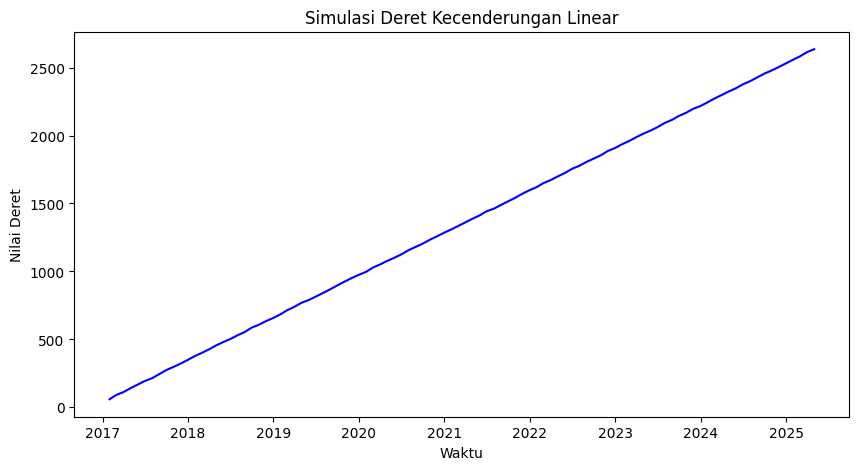

In [55]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

**Jawab:**

Dari plot deret waktu, terlihat nilai deret naik terus secara konsisten seiring bertambahnya waktu, membentuk garis yang hampir lurus dari sekitar 0 di tahun 2017 sampai mendekati 5250 di tahun 2025. Kenaikannya sangat mulus, hampir tidak ada gangguan/noise yang terlihat, jadi bisa dibilang pola naiknya ini benar-benar didorong oleh waktu itu sendiri, bukan cuma kebetulan.

Hasil hitung korelasi antara waktu dan nilai deret dapat 1.0000 — artinya hubungannya linear positif dan hampir sempurna. Ini masuk akal karena "gangguan acak" yang ditambahkan ke data memang dibuat kecil, jadi tidak banyak mengaburkan pola naik yang sebenarnya. Perlu diingat, korelasi ini menunjukkan hubungan antara waktu dan nilai data — bukan hubungan antar data itu sendiri (misalnya data hari ini dibanding data kemarin), yang biasanya disebut autokorelasi. Autokorelasi ini akan dicek belakangan, setelah kita punya sisaan dari model regresi.

In [56]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [57]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.301e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.50e-253
Time:                        12:34:15   Log-Likelihood:                -214.13
No. Observations:                 100   AIC:                             432.3
Df Residuals:                      98   BIC:                             437.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           62.5722      0.413    151.530   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

**Jawab:**

Data simulasi dibangkitkan menggunakan parameter asli β₀ = 62 dan β₁ = 26. Setelah model regresi linear dipaskan pada data tersebut, diperoleh dugaan intersep sebesar 62,5722 dan koefisien Time_Numeric sebesar 52,4930, sehingga model regresi yang terbentuk dapat dituliskan sebagai:

$$ \hat{Y}_t = 62,5722 + 25.9930t $$

Kedua nilai dugaan ini berada sangat dekat dengan parameter aslinya — selisih intersep hanya sekitar 0,57 dan selisih koefisien waktu hanya sekitar 0,01. Kedekatan ini menunjukkan bahwa metode kuadrat terkecil mampu menangkap kembali struktur kecenderungan yang sebenarnya menyusun data, tanpa terlalu terpengaruh oleh gangguan acak (noise) yang ditambahkan pada saat simulasi.

Apakah model regresi yang dipaskan sudah bagus?

**Jawab:**

Model regresi yang dipaskan sudah sangat baik dalam menggambarkan kecenderungan deret. Hal tersebut ditunjukkan oleh nilai $R^2 = 1{,}000$ dan adjusted $R^2 = 1{,}000$, yang menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh variabel waktu.

Selain itu, koefisien Time memiliki $p\text{-value} = 0{,}000 < 0{,}05$, sehingga terdapat bukti yang cukup bahwa waktu berpengaruh secara signifikan terhadap nilai deret. Hasil estimasi koefisien ($25{,}9930$, mendekati $\beta_1=26$) yang sangat dekat dengan parameter asli semakin mendukung bahwa model berhasil menangkap pola linear pada data.

Dengan demikian, model regresi linear dapat dikatakan sangat baik dalam menggambarkan kecenderungan linear deret. Meskipun demikian, nilai $R^2$ yang tinggi belum cukup untuk memastikan bahwa model telah memenuhi seluruh asumsi regresi, sehingga pemeriksaan terhadap residual tetap diperlukan.

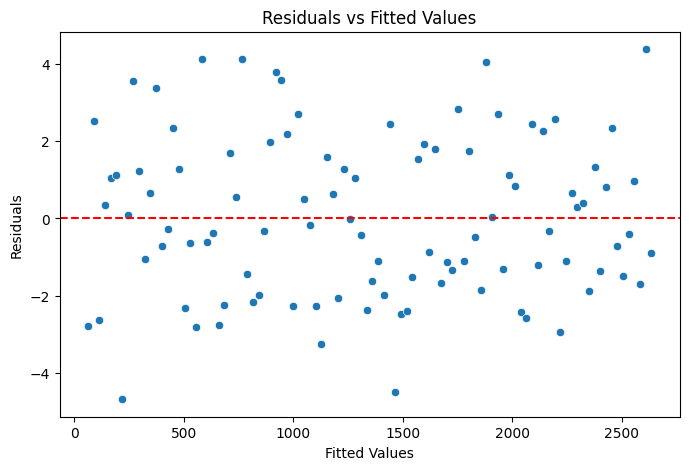

In [58]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

**Jawab:**

Berdasarkan plot Residuals vs Fitted Values, residual tersebar di sekitar garis nol dan tidak menunjukkan pola tertentu yang jelas. Titik residual positif dan negatif muncul pada berbagai nilai fitted value dengan penyebaran yang relatif merata.

Tidak terlihat adanya pola melengkung maupun pola yang semakin melebar atau menyempit secara sistematis (pola kipas). Kondisi tersebut menunjukkan bahwa secara visual hubungan linear telah sesuai dan tidak terlihat adanya perubahan ragam residual yang mencolok.

Dengan demikian, berdasarkan plot tersebut tidak terdapat indikasi kuat adanya pelanggaran terhadap asumsi linearitas maupun homoskedastisitas.

In [59]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.1615


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

**Jawab:**

Hasil uji Breusch–Pagan menghasilkan p-value sebesar $0{,}1615$. Dengan menggunakan taraf signifikansi 5%, karena ($0{,}1615>0{,}05$), maka tidak terdapat cukup bukti untuk menolak hipotesis nol yang menyatakan bahwa ragam residual konstan. Dengan demikian, tidak terdapat indikasi heteroskedastisitas pada model. Hasil uji ini mendukung kesimpulan dari plot Residuals vs Fitted Values bahwa asumsi homoskedastisitas dapat diterima.

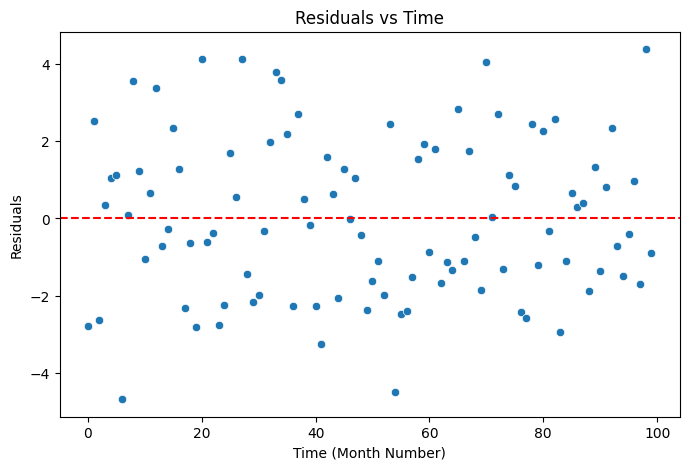

In [60]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

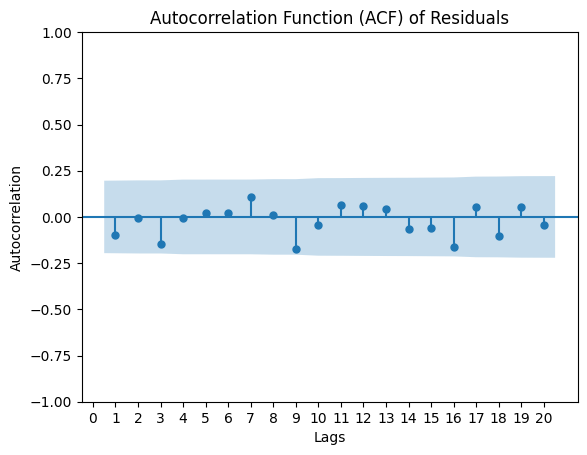

In [61]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

**Jawab:**

Pada plot ACF residual, nilai autokorelasi pada lag 1 sampai lag 20 berada di dalam batas kepercayaan yang ditampilkan. Tidak terdapat spike yang secara jelas melewati batas tersebut. Hal ini menunjukkan bahwa tidak terdapat autokorelasi residual yang signifikan pada lag-lag yang diperiksa. Dengan demikian, residual dapat dianggap tidak memiliki pola ketergantungan waktu yang kuat.

In [62]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.953117   0.328927
2    0.955259   0.620252
3    3.247156   0.355066
4    3.254160   0.516228
5    3.311165   0.652133
6    3.370514   0.761110
7    4.613936   0.706958
8    4.624140   0.796889
9    7.944405   0.539758
10   8.167926   0.612438
11   8.652003   0.653979
12   9.032411   0.700160
13   9.255167   0.753410
14   9.800825   0.776596
15  10.269623   0.802446
16  13.461671   0.638750
17  13.796059   0.681482
18  15.168715   0.650352
19  15.503393   0.690111


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

**Jawab:**

Berdasarkan hasil uji Ljung-Box, seluruh p-value dari lag 1 sampai lag 19 (sesuai lags=range(1,20) pada kode) lebih besar dari $0{,}05$. Oleh karena itu, $H_0$ tidak ditolak pada seluruh lag yang diuji. Dengan demikian, tidak terdapat cukup bukti adanya autokorelasi residual secara bersama-sama sampai lag yang diuji. Hasil ini menunjukkan bahwa residual dapat dianggap tidak memiliki autokorelasi yang signifikan.

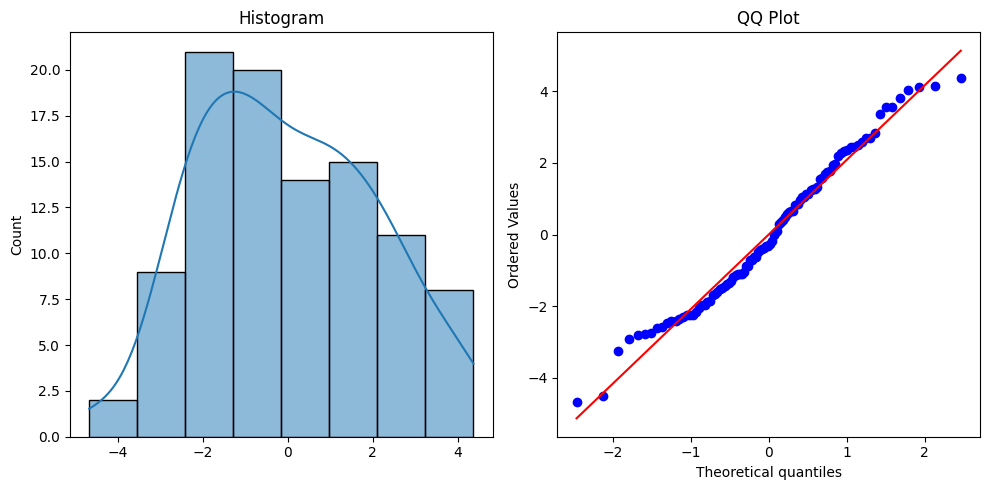

In [63]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

**Jawab:**

Histogram residual menunjukkan bahwa residual secara umum terkonsentrasi di sekitar nilai nol dan memiliki bentuk yang menyerupai distribusi normal. Pada QQ Plot, sebagian besar titik berada cukup dekat dengan garis lurus, walaupun terdapat sedikit penyimpangan terutama pada bagian ekor. Oleh karena itu, secara visual residual dapat dikatakan cukup mendekati distribusi normal, meskipun tidak sepenuhnya sempurna.

In [64]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9783558042906755, p-value = 0.09889205851809933


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

**Jawab:**

Uji Shapiro-Wilk menghasilkan statistik sebesar 0,9783558 dengan p-value 0,0988921. Karena p-value lebih besar dari 0,05, maka hipotesis nol tidak ditolak. Dengan demikian, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Kesimpulan ini sejalan dengan histogram dan QQ Plot, yang menunjukkan bahwa residual secara umum masih cukup mengikuti pola distribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [65]:
# Menentukan parameter simulasi
np.random.seed(1052)
n_periods = 120
beta_0, beta_1, beta_2= 102, 26, 1.04
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

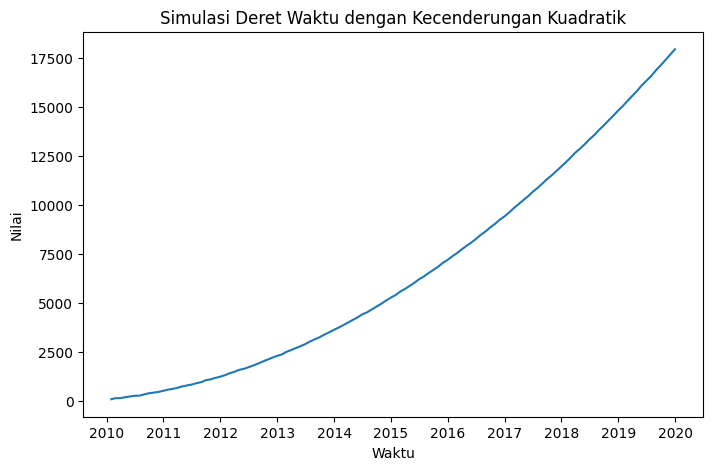

In [66]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**Jawab:**

Deret menunjukkan kecenderungan meningkat dengan pola melengkung ke atas. Kenaikan nilai semakin besar seiring bertambahnya waktu, sehingga laju pertumbuhannya tidak konstan. Pola ini berbeda dengan kecenderungan linear yang berbentuk garis lurus dengan kenaikan yang relatif konstan. Oleh karena itu, deret pada bagian ini menunjukkan kecenderungan kuadratik.

In [67]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.599e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          9.09e-319
Time:                        12:34:16   Log-Likelihood:                -448.37
No. Observations:                 120   AIC:                             902.7
Df Residuals:                     117   BIC:                             911.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        106.3411      2.769     38.406      0.0

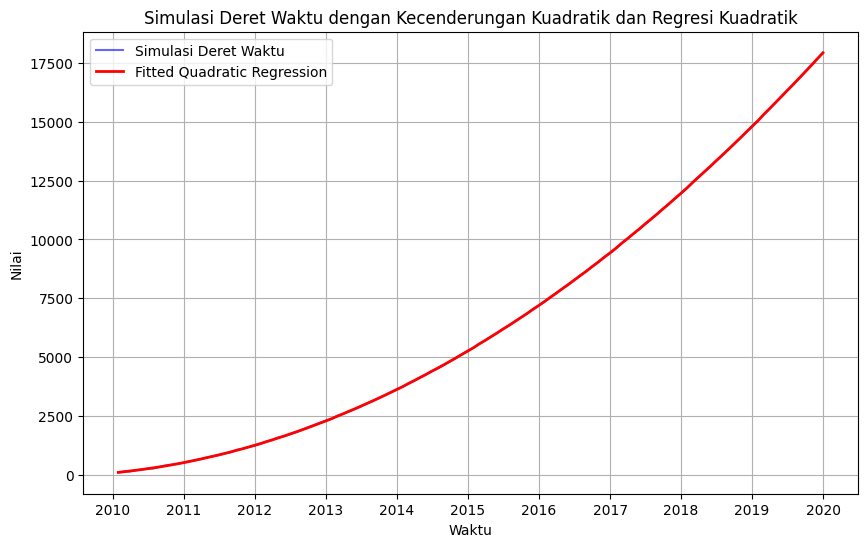

In [68]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

**Jawab:**

Berdasarkan hasil regresi kuadratik, diperoleh $R^2 = 1{,}000$ dan adjusted $R^2 = 1{,}000$, sehingga model mampu menjelaskan hampir seluruh variasi data. Koefisien intersep sebesar $106{,}3411$, koefisien $x_1$ (waktu) sebesar $25{,}8721$, dan koefisien $x_2$ (waktu²) sebesar $1{,}0409$, dengan seluruh p-value sebesar $0{,}000$ — nilai-nilai ini sangat dekat dengan parameter simulasi asli ($\beta_0=102$, $\beta_1=26$, $\beta_2=1{,}04$).

Untuk residual, nilai Prob(Jarque-Bera) $=0{,}326$, sehingga lebih besar dari $0{,}05$ dan tidak terdapat cukup bukti bahwa residual tidak normal. Nilai Durbin-Watson $= 2{,}266$, yang cukup dekat dengan 2, juga tidak menunjukkan adanya autokorelasi yang kuat.

Namun, output memberikan catatan bahwa condition number sangat besar, yaitu sekitar $1{,}88\times10^4$, yang mengindikasikan adanya korelasi tinggi antara variabel $t$ dan $t^2$ (karena keduanya berasal dari variabel yang sama). Jadi, dari sisi residual model terlihat baik, tetapi terdapat peringatan numerik yang perlu diperhatikan.

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

**Jawab:**

Model regresi kuadratik dapat dikatakan tepat untuk deret tersebut karena bentuk model sesuai dengan pola data yang melengkung ke atas. Garis hasil regresi juga hampir berimpit dengan deret simulasi, menunjukkan bahwa model mampu mengikuti pola data dengan sangat baik. Selain itu, nilai $R^2=1{,}000$ dan koefisien hasil estimasi sangat dekat dengan parameter yang digunakan untuk membentuk data. Dengan demikian, model kuadratik lebih sesuai dibandingkan model linear untuk menggambarkan deret tersebut.

In [69]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [70]:
# Menentukan parameter simulasi
np.random.seed(1052)
n_periods = 120
beta0, beta1, beta2= 102, -1.300, -104
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


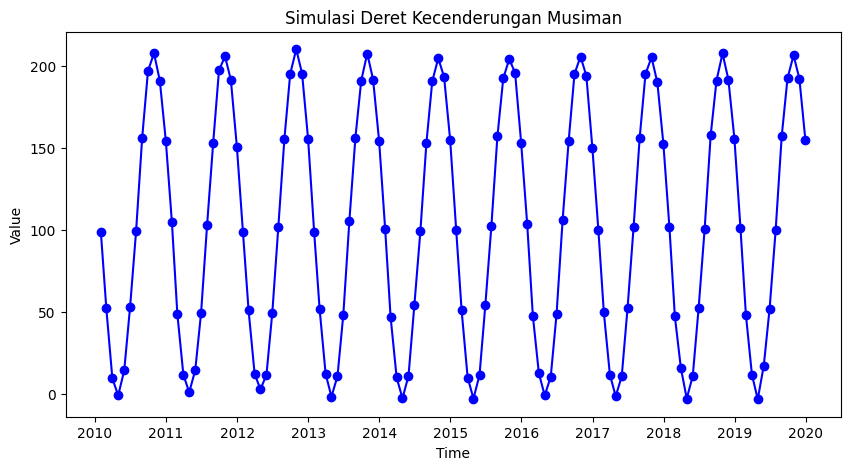

In [71]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

**Jawab:**

Plot menunjukkan pola naik dan turun yang berulang secara teratur setiap 12 periode. Nilai deret mencapai titik tinggi kemudian turun ke titik rendah dan pola tersebut kembali muncul pada periode berikutnya. Karena data menggunakan frekuensi bulanan, periode 12 menunjukkan pola yang berulang setiap satu tahun. Dengan demikian, deret memiliki kecenderungan musiman dengan periode 12, yaitu nilai pada bulan-bulan tertentu cenderung mengikuti pola yang sama dari tahun ke tahun.

In [72]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [73]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [74]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [75]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.425e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.68e-165
Time:                        12:34:17   Log-Likelihood:                -249.60
No. Observations:                 120   AIC:                             523.2
Df Residuals:                     108   BIC:                             556.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      100.7107      0.646    155.989      0.0

Bagaimana interpretasi dari hasil tersebut?

**Jawab:**

Hasil regresi tanpa intersep menghasilkan 12 koefisien yang masing-masing langsung merepresentasikan nilai rata-rata deret untuk setiap bulan (karena tidak ada kategori referensi). Dari output diperoleh rata-rata: Januari = 100,7107; Februari = 49,3415; Maret = 11,5844; April = −1,4685; Mei = 12,1568; Juni = 51,2375; Juli = 101,8187; Agustus = 155,3789; September = 193,6328; Oktober = 206,5049; November = 192,5577; dan Desember = 153,4447.

Seluruh koefisien signifikan pada taraf 5% (p-value ≤ 0,025 untuk semua bulan, termasuk April yang p-value-nya 0,025). Nilai rata-rata tertinggi terdapat pada Oktober (206,5049), sedangkan nilai terendah terdapat pada April (−1,4685). Pola ini menunjukkan adanya perbedaan rata-rata yang jelas antarbulan dan mendukung adanya pola musiman, dengan puncak di sekitar Agustus–November dan titik terendah di sekitar Maret–April.

In [76]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

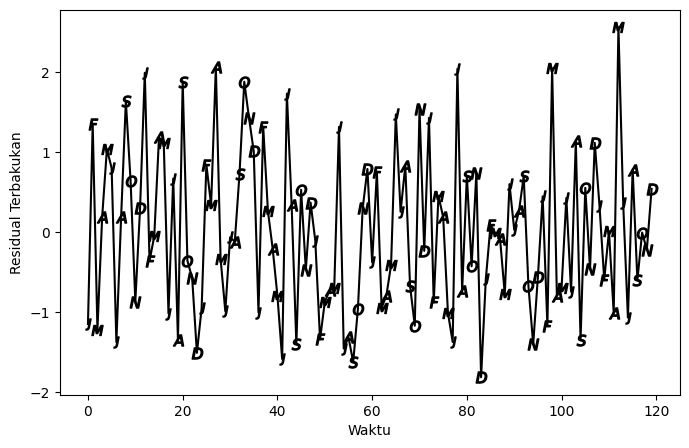

In [77]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


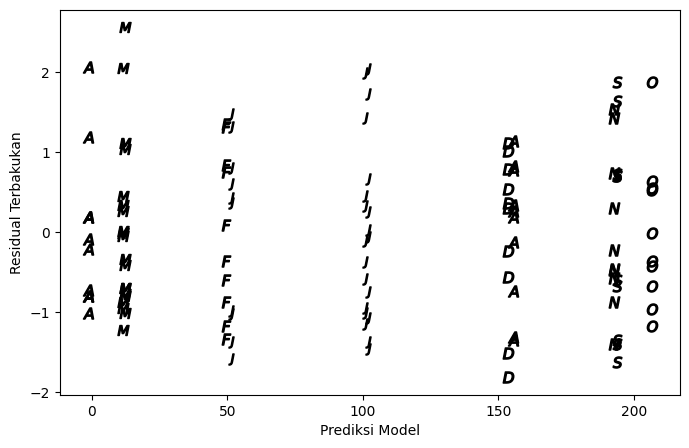

In [78]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

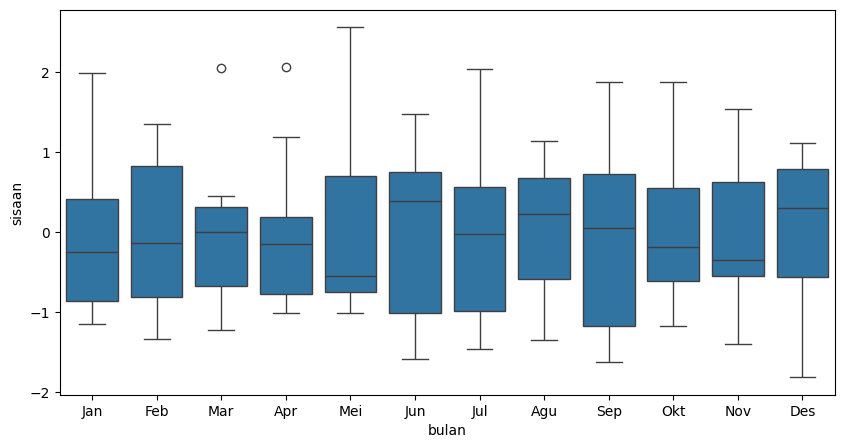

In [79]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

**Jawab:**

Pada plot residual terstandardisasi terhadap waktu, residual berfluktuasi di sekitar nol dan tidak menunjukkan pola musiman yang jelas. Pada plot residual terhadap prediksi model, residual juga tersebar pada berbagai nilai prediksi dan tidak membentuk pola tertentu yang kuat. Sementara itu, boxplot residual berdasarkan bulan menunjukkan bahwa median residual sebagian besar berada di sekitar nol, tetapi penyebaran residual berbeda antarbulan dan terdapat beberapa pencilan, terutama pada beberapa bulan seperti Maret dan April. Secara keseluruhan, tidak terlihat pola musiman yang kuat pada residual sehingga komponen musiman utama sudah cukup berhasil ditangkap oleh model.

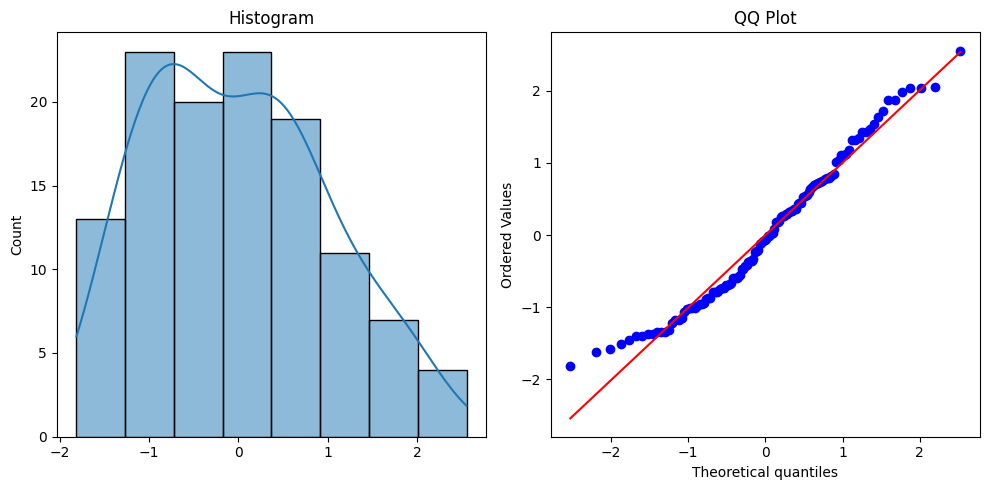

In [80]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

**Jawab:**

Berdasarkan histogram dan QQ Plot, residual secara umum memiliki pola yang mendekati distribusi normal. Sebagian besar titik pada QQ Plot mengikuti garis diagonal, meskipun terdapat beberapa penyimpangan pada bagian ekor. Selain itu, residual dari ketiga plot sebelumnya tidak menunjukkan pola sistematis yang kuat. Dengan demikian, model dapat dikatakan cukup tepat dalam menangkap pola musiman, walaupun asumsi normalitas residual tidak terlihat sempurna. Oleh karena itu, model sudah cukup baik untuk menggambarkan pola utama deret, tetapi masih terdapat beberapa penyimpangan pada residual.

In [81]:
# ==========================================
# UJI ASUMSI MODEL MUSIMAN
# ==========================================

# 1. Uji normalitas Shapiro-Wilk
from scipy import stats

shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)

print("Shapiro-Wilk Test")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)

# 2. Uji autokorelasi Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    musiman.resid,
    lags=[12],
    return_df=True
)

print("\nLjung-Box Test")
print(ljung_box)

# 3. Uji homoskedastisitas Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

# Membuat matriks X untuk uji Breusch-Pagan
# Menggunakan intercept + dummy bulan
X_bp = sm.add_constant(musim.iloc[:, 1:])

bp_test = het_breuschpagan(musiman.resid, X_bp)

print("\nBreusch-Pagan Test")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])

Shapiro-Wilk Test
Statistic = 0.9710653376236315
p-value = 0.010890159102578083

Ljung-Box Test
      lb_stat  lb_pvalue
12  10.572148   0.565897

Breusch-Pagan Test
LM Statistic = 5.332607565537386
LM p-value = 0.9139950553412298
F Statistic = 0.4565945865855629
F p-value = 0.9256688692409156


Hitunglah statistik uji untuk mengecek asumsi model

**Jawab:**

Berdasarkan hasil uji asumsi model:

Shapiro-Wilk menghasilkan statistik $W=0{,}9711$ dengan p-value $=0{,}0109 < 0{,}05$, sehingga $H_0$ ditolak dan residual tidak berdistribusi normal.

Uji Ljung-Box pada lag 12 menghasilkan $LB=10{,}5721$ dengan p-value $=0{,}5659 > 0{,}05$, sehingga $H_0$ gagal ditolak dan tidak terdapat bukti autokorelasi residual hingga lag 12.

Uji Breusch-Pagan menghasilkan LM Statistic $=5{,}3326$ (p-value $=0{,}9140$) dan F Statistic $=0{,}4566$ (p-value $=0{,}9257$). Karena kedua p-value $>0{,}05$, maka $H_0$ gagal ditolak sehingga tidak terdapat bukti heteroskedastisitas.

Dengan demikian, model memenuhi asumsi tidak adanya autokorelasi dan homoskedastisitas, tetapi asumsi normalitas residual tidak terpenuhi.

In [82]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [83]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [84]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.425e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.68e-165
Time:                        12:34:19   Log-Likelihood:                -249.60
No. Observations:                 120   AIC:                             523.2
Df Residuals:                     108   BIC:                             556.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.7107      0.646    155.989      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

**Jawab:**

Model dengan intersep dan tanpa intersep menghasilkan pola musiman yang sama secara substansi ($R^2=0{,}999$ pada keduanya), tetapi menggunakan parameterisasi berbeda.

Pada model dengan intersep, Januari digunakan sebagai kategori acuan. Nilai const sebesar $100{,}7107$ menunjukkan rata-rata nilai deret pada bulan Januari — sama dengan koefisien Januari pada model tanpa intersep. Koefisien bulan lain menyatakan selisih rata-rata bulan tersebut terhadap Januari. Misalnya, koefisien Februari $=-51{,}3692$ berarti rata-rata Februari lebih rendah $51{,}3692$ dibanding Januari: $100{,}7107 + (-51{,}3692) = 49{,}3415$, sesuai dengan koefisien Februari pada model tanpa intersep. Koefisien Oktober $=105{,}7941$ berarti rata-rata Oktober lebih tinggi $105{,}7941$ dibanding Januari: $100{,}7107+105{,}7941=206{,}5049$, juga sesuai dengan model tanpa intersep.

Pada model tanpa intersep, setiap koefisien bulan langsung menyatakan rata-rata nilai deret bulan tersebut tanpa perlu dijumlahkan dengan konstanta apa pun. Model tanpa intersep memudahkan pembacaan rata-rata tiap bulan secara langsung, sedangkan model dengan intersep memudahkan pengujian apakah suatu bulan berbeda signifikan dari bulan acuan (Januari).

Apakah model dengan intersep sudah memenuhi asumsi regresi?

**Jawab:**

Model dengan intersep menghasilkan $R^2=0{,}999$ dan adjusted $R^2=0{,}999$, sehingga model mampu menjelaskan sekitar $99{,}9%$ variasi data — identik dengan model tanpa intersep karena keduanya ekuivalen secara matematis.

Nilai Durbin-Watson sebesar $2{,}305$ cukup dekat dengan 2 sehingga tidak menunjukkan indikasi kuat adanya autokorelasi. Uji Jarque-Bera menghasilkan p-value $=0{,}0844>0{,}05$, sehingga tidak terdapat cukup bukti bahwa residual tidak berdistribusi normal. Namun, Prob(Omnibus) $=0{,}027<0{,}05$ menunjukkan indikasi penyimpangan normalitas, konsisten dengan hasil uji Shapiro-Wilk formal (p-value $=0{,}0109$) yang juga menolak normalitas.

Dengan demikian, model memiliki kecocokan yang sangat baik dan tidak menunjukkan masalah autokorelasi. Akan tetapi, asumsi normalitas residual tidak terpenuhi secara formal.




In [85]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [86]:
# Parameter
np.random.seed(1052)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 26, 520 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


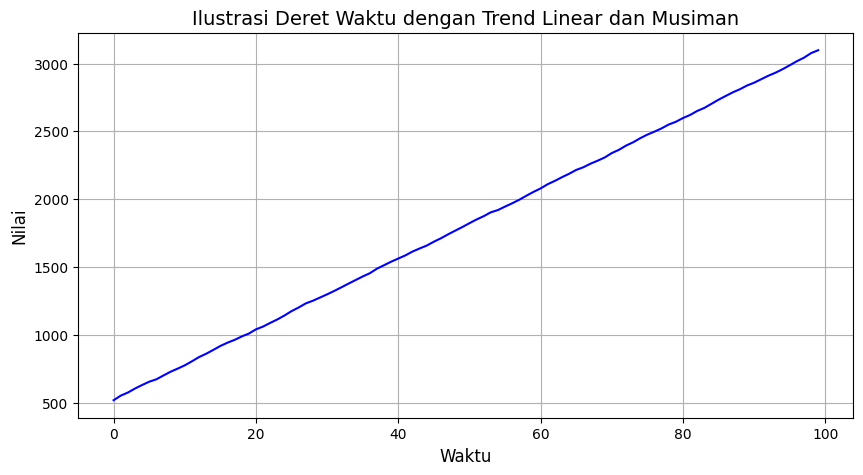

In [87]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [88]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [89]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [90]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.094e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          9.67e-220
Time:                        12:34:19   Log-Likelihood:                -207.71
No. Observations:                 100   AIC:                             441.4
Df Residuals:                      87   BIC:                             475.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      520.3311      0.772    674.297      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

**Jawab:**

Pada model ini digunakan komponen musiman sekaligus variabel period untuk menangkap kecenderungan linear. Koefisien masing-masing bulan (Januari $=520{,}3311$; Februari $=523{,}4940$; Maret $=525{,}0354$; April $=526{,}1632$; Mei $=523{,}8266$; Juni $=522{,}8039$; Juli $=519{,}3483$; Agustus $=517{,}6891$; September $=517{,}4640$; Oktober $=515{,}7877$; November $=517{,}4003$; Desember $=518{,}1015$) menunjukkan tingkat nilai deret berdasarkan pola musiman, sedangkan koefisien period menunjukkan perubahan nilai deret akibat pertambahan waktu.

Koefisien period sebesar $25{,}9919$ berarti bahwa setiap kenaikan satu periode waktu dikaitkan dengan peningkatan rata-rata nilai deret sekitar $25{,}99$ satuan, setelah memperhitungkan komponen musiman dalam model. Koefisien tersebut memiliki p-value $=0{,}000$, sehingga signifikan secara statistik.

Koefisien bulanan juga menunjukkan adanya perbedaan tingkat nilai deret antarbulan. Sebagai contoh, koefisien April ($526{,}1632$) lebih tinggi dibandingkan Januari ($520{,}3311$), sedangkan September ($517{,}4640$) lebih rendah dibandingkan Januari. Dengan demikian, model menunjukkan adanya dua pola sekaligus, yaitu kecenderungan meningkat dari waktu ke waktu dan variasi musiman antarbulan.


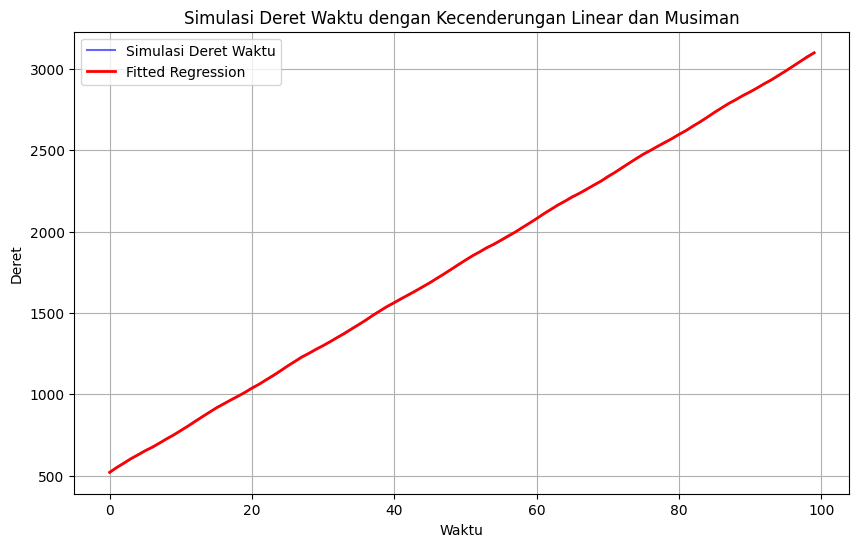

In [91]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
# ==========================================
# UJI ASUMSI MODEL MIX
# ==========================================

# 1. Uji normalitas Shapiro-Wilk
from scipy import stats

shapiro_stat, shapiro_p = stats.shapiro(model_mix.resid)

print("Shapiro-Wilk Test")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)


# 2. Uji autokorelasi Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_mix.resid,
    lags=[12],
    return_df=True
)

print("\nLjung-Box Test")
print(ljung_box)


# 3. Uji homoskedastisitas Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

X_bp = sm.add_constant(np.asarray(x))

bp_test = het_breuschpagan(model_mix.resid, X_bp)

print("\nBreusch-Pagan Test")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])

Shapiro-Wilk Test
Statistic = 0.9768121845627733
p-value = 0.07483285603459722

Ljung-Box Test
      lb_stat  lb_pvalue
12  11.120061   0.518658

Breusch-Pagan Test
LM Statistic = 0.8514956219352721
LM p-value = 0.35612957765197584
F Statistic = 0.8416321705818722
F p-value = 0.36118263090450475


Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

**Jawab:**

Berdasarkan output model diperoleh $R^2=1{,}000$ dan adjusted $R^2=1{,}000$, sehingga model memiliki kecocokan yang sangat tinggi terhadap data. Nilai Durbin-Watson sebesar $2{,}210$ cukup dekat dengan 2 sehingga tidak menunjukkan indikasi kuat adanya autokorelasi residual. Uji Jarque-Bera menghasilkan p-value $=0{,}160>0{,}05$, sehingga tidak terdapat cukup bukti bahwa residual tidak berdistribusi normal, meskipun Prob(Omnibus) $=0{,}016<0{,}05$ menunjukkan indikasi berlawanan.

Hasil ini diperjelas oleh uji formal yang dijalankan pada residual: Shapiro-Wilk ($W=0{,}9768$, p-value $=0{,}0748$) mendukung normalitas, Ljung-Box lag 12 ($LB=11{,}1201$, p-value $=0{,}5187$) tidak menunjukkan autokorelasi, dan Breusch-Pagan (LM p-value $=0{,}3561$; F p-value $=0{,}3612$) tidak menunjukkan heteroskedastisitas.

Dengan demikian, tidak terdapat indikasi kuat adanya autokorelasi maupun heteroskedastisitas. Untuk normalitas, mayoritas uji (Jarque-Bera dan Shapiro-Wilk) mendukung residual normal, sehingga secara keseluruhan tidak terdapat pelanggaran asumsi yang serius pada model ini.

In [93]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [94]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

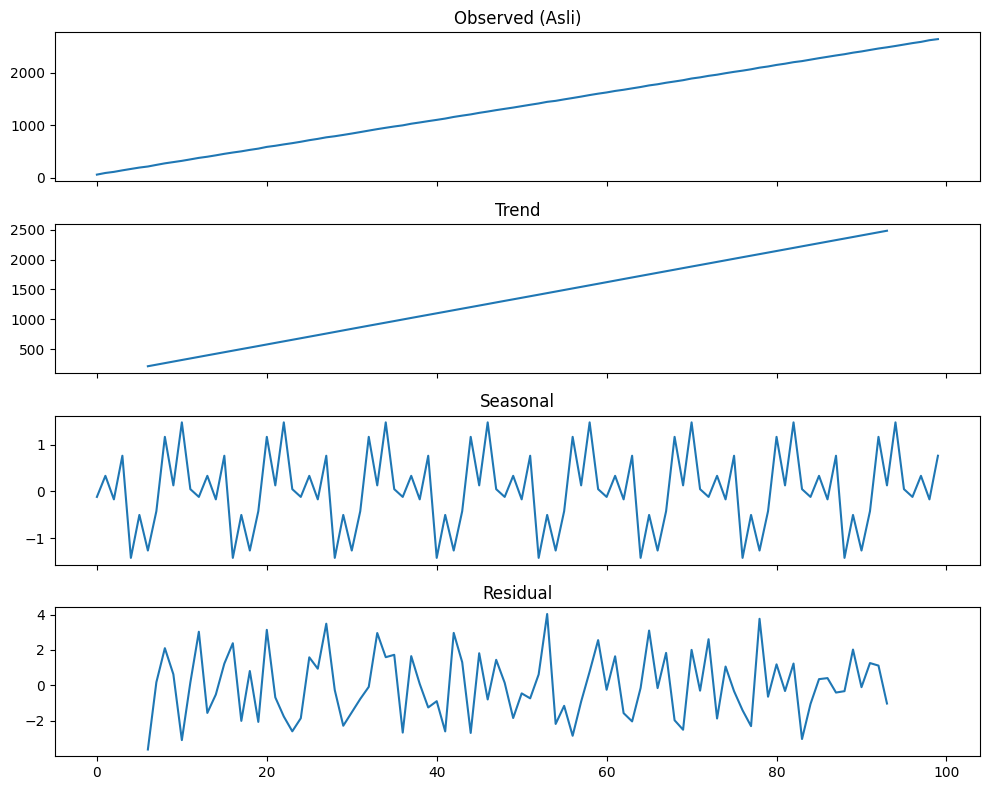

In [95]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawab:**

Pada hasil dekomposisi deret linear, komponen Observed menunjukkan data aktual yang mengalami fluktuasi dari waktu ke waktu. Komponen Trend menunjukkan kecenderungan jangka panjang dari deret, sedangkan komponen Seasonal menunjukkan pola berulang secara periodik. Komponen Residual merupakan variasi yang tersisa setelah pengaruh trend dan seasonal dikeluarkan dari deret, berfluktuasi di sekitar nol tanpa pola yang teratur. Dengan demikian, hasil dekomposisi menunjukkan bahwa deret dapat dipisahkan menjadi tiga komponen utama, yaitu kecenderungan jangka panjang, pola musiman, dan variasi yang tidak dapat dijelaskan oleh kedua komponen tersebut.

In [96]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

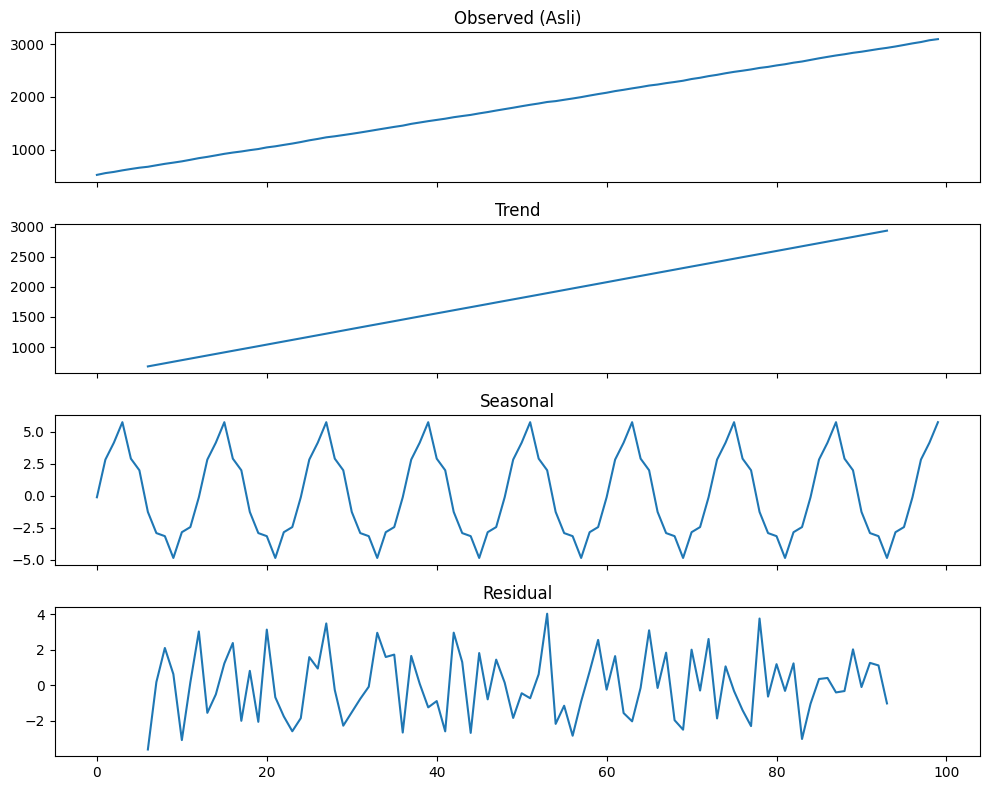

In [97]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawab:**

Pada dekomposisi deret dengan kecenderungan linear dan musiman, komponen Observed menunjukkan deret yang meningkat seiring waktu sekaligus memiliki pola naik-turun yang berulang. Komponen Trend memperlihatkan peningkatan yang hampir linear, sesuai dengan komponen trend pada simulasi. Komponen Seasonal menunjukkan pola sinusoidal yang berulang setiap 12 periode dengan amplitudo relatif konstan. Komponen Residual berfluktuasi di sekitar nol tanpa pola sistematis. Dengan demikian, dekomposisi berhasil memisahkan kecenderungan linear dan pola musiman dari variasi acak dalam deret.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [98]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1052)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.6, 520 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

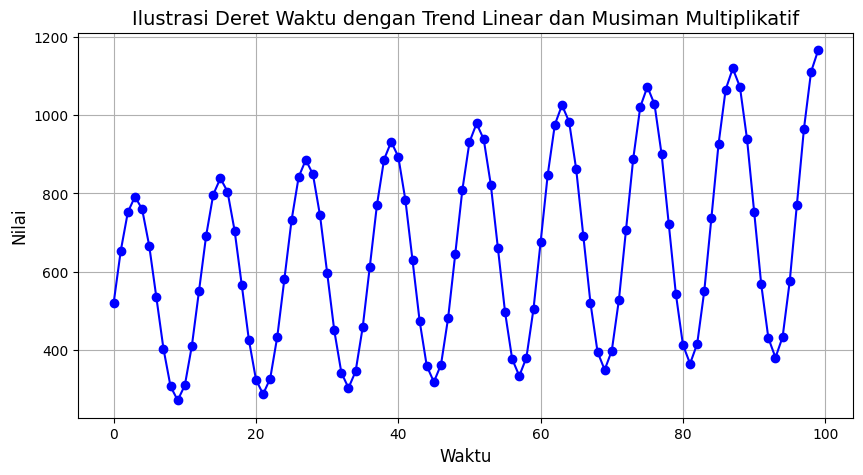

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [100]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

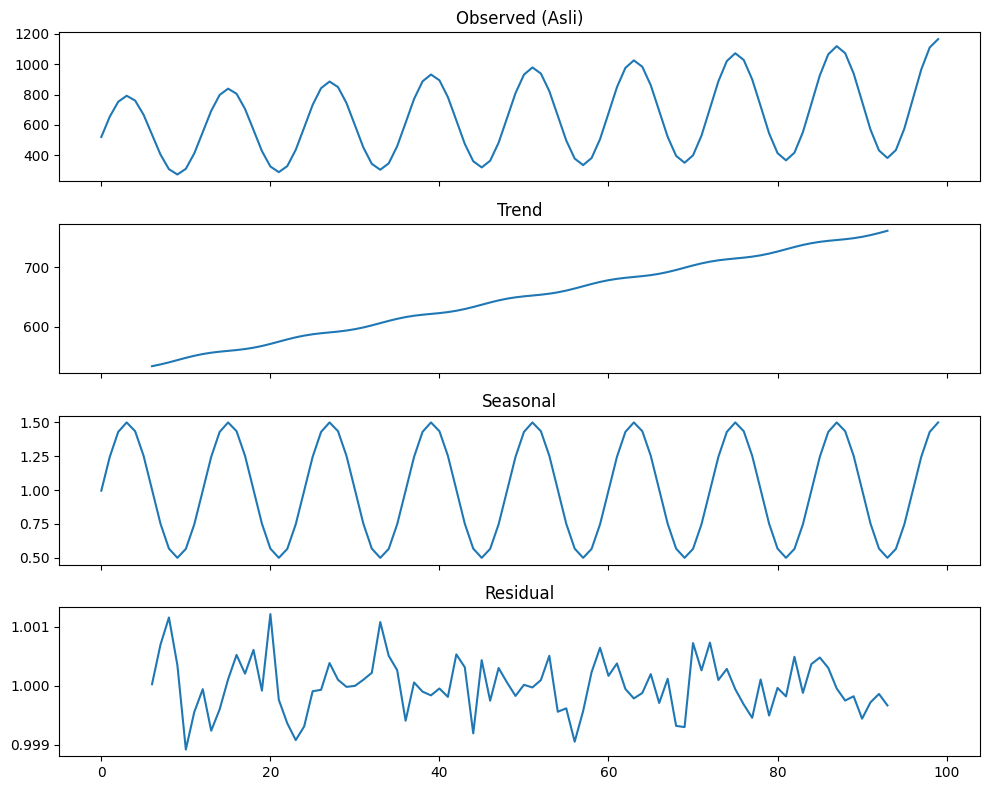

In [101]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

**Jawab:**

Pada deret multiplikatif, plot observed menunjukkan dua karakteristik sekaligus, yaitu tren yang meningkat dan pola musiman yang berulang, dengan besar fluktuasi musiman yang terlihat semakin membesar seiring meningkatnya level deret. Karakteristik inilah yang menjadi alasan model multiplikatif lebih sesuai digunakan di sini dibandingkan model aditif, karena besarnya efek musiman memang bergantung pada tingkat/level deret, bukan tetap konstan. Komponen trend menunjukkan peningkatan secara bertahap, komponen seasonal berbentuk rasio yang berulang setiap 12 periode (berpusat di sekitar nilai 1, bukan nol seperti pada model aditif), dan komponen residual menunjukkan sisa variasi berupa rasio di sekitar 1 setelah pengaruh trend dan seasonal dipisahkan.

Secara umum, bentuk model multiplikatif dapat dituliskan sebagai $Y_t = T_t \times S_t \times R_t$, dengan $T_t$ menyatakan komponen trend, $S_t$ menyatakan komponen seasonal, dan $R_t$ menyatakan komponen residual.

Dengan demikian, model multiplikatif memang lebih tepat digunakan ketika amplitudo variasi musiman cenderung membesar mengikuti level deret. Perlu diperhatikan pula bahwa dekomposisi dengan model multiplikatif hanya dapat dilakukan pada deret yang bernilai positif ($Y_t > 0$ untuk semua $t$), sehingga jika deret memiliki nilai nol atau negatif, deret tersebut perlu ditransformasi terlebih dahulu sebelum dekomposisi dapat dilakukan.

In [102]:
# Parameter
np.random.seed(1052)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

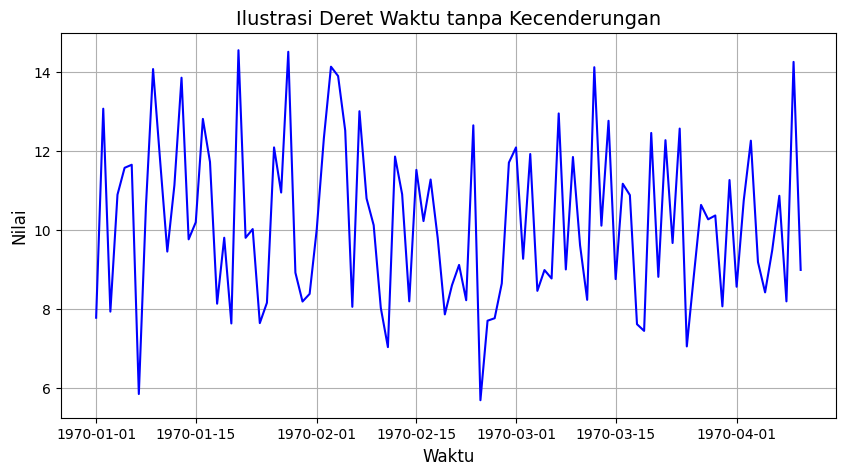

In [103]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

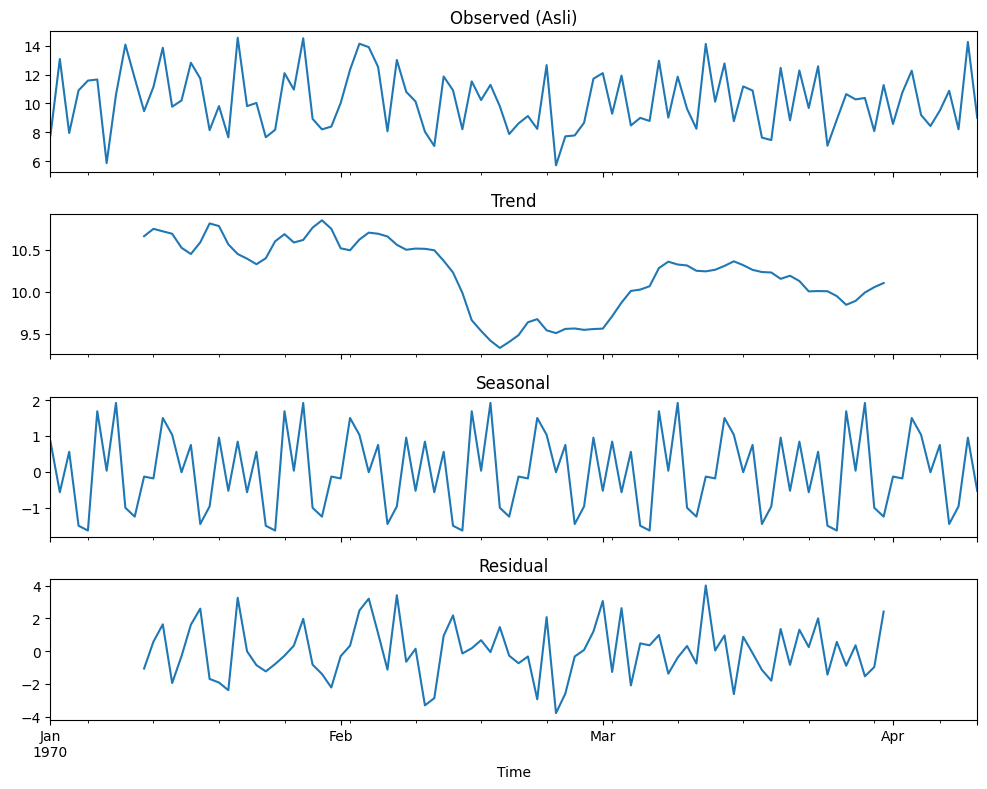

In [104]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

**Jawab:**

Berdasarkan hasil dekomposisi, deret asli (Observed) berfluktuasi pada kisaran sekitar 6 hingga 14 tanpa menunjukkan kecenderungan kenaikan atau penurunan yang konsisten sepanjang waktu. Komponen Trend mengalami beberapa perubahan, yaitu menurun dari sekitar 10,5 hingga mencapai sekitar 9,4, kemudian meningkat kembali hingga sekitar 10,2 pada akhir periode. Dengan demikian, komponen Trend tidak menunjukkan kecenderungan jangka panjang yang kuat dan konsisten.

Komponen Seasonal menunjukkan pola yang berulang secara teratur dengan periode 12, dengan nilai yang berfluktuasi sekitar −2 hingga 2. Pola puncak dan lembah yang berulang menunjukkan adanya pola musiman pada deret. Sementara itu, komponen Residual berfluktuasi di sekitar nol, dengan nilai sekitar −4 hingga 4, dan tidak menunjukkan pola sistematis yang jelas.

Secara keseluruhan, deret tidak memiliki kecenderungan (trend) jangka panjang yang kuat, tetapi menunjukkan pola musiman yang cukup jelas dan berulang setiap 12 periode. Variasi yang tersisa setelah komponen trend dan seasonal dipisahkan cenderung bersifat acak. Nilai trend dan residual yang kosong pada bagian awal dan akhir periode terjadi karena metode dekomposisi menggunakan moving average, sehingga tidak tersedia cukup pengamatan di sekitar titik tersebut untuk menghitung komponennya.